
##  Loading Libraries & Dataset
#

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
    
from IPython.display import display  # print() can only print text , for tabular multiple tabular 
                                     # dataframes to print in a single cell we use display()

import warnings 
warnings.filterwarnings('ignore') # as some functions maybe depricated in future versions to ignore the 
                                  # messages of these updates we ignore them}

In [24]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
df = pd.read_csv('../data/01_cleaned_heart_data.csv')
display(df.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


#
## 3) Data Preprocessing
#

##
### 3.1 - Label Encoding Binary Categorical Variables
##

- ML Algorithms cannot understand and handle text like ATA / Normal / M / F 
- We need to encode them to numbers 
- For Binary Categories ( 2 values like Male/Female) , we encode them to 0/1 manaully ..

In [26]:
categorical_df = df.select_dtypes(include = 'object')
display(categorical_df.head(1))

categorical_columns = categorical_df.columns
display(categorical_df.columns)

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up


Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

- Above are the categorical Columns of the dataset

In [27]:
for col in categorical_columns : 
    unique_count  = df[col].nunique()   # df['col_name'].nunique() gives us total number of unique values in column
    unique_values = df[col].unique()    # df['col_name'].unique() gives us list of unique values of required column
    print(f"Column : {col:<20} | Unique Count: {unique_count:<12} | Values: {unique_values}")

Column : Sex                  | Unique Count: 2            | Values: ['M' 'F']
Column : ChestPainType        | Unique Count: 4            | Values: ['ATA' 'NAP' 'ASY' 'TA']
Column : RestingECG           | Unique Count: 3            | Values: ['Normal' 'ST' 'LVH']
Column : ExerciseAngina       | Unique Count: 2            | Values: ['N' 'Y']
Column : ST_Slope             | Unique Count: 3            | Values: ['Up' 'Flat' 'Down']


##### Binary Categorical Columnns     :  Sex / ExerciseAngina
##### Multi-Class Categorical Columns :  ChestPainType / RestingECG / ST_Slope

In [28]:
sex_mapping = {
    'M': 1 ,
    'F': 0 
}
df['Sex'] = df['Sex'].map(sex_mapping)

angina_mapping = {
    'Y': 1 , 
    'N': 0
}
df['ExerciseAngina'] = df['ExerciseAngina'].map(angina_mapping)

In [29]:
display(df.head())
display(df[['Sex', 'ExerciseAngina']].info())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140.0,289.0,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160.0,180.0,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130.0,283.0,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138.0,214.0,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150.0,195.0,0,Normal,122,0,0.0,Up,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Sex             918 non-null    int64
 1   ExerciseAngina  918 non-null    int64
dtypes: int64(2)
memory usage: 14.5 KB


None

- We can verify here binary categorical variables are encoded to 0/1 Integers

##
### 3.1 - One Hot Encoding Multi-Class Categorical Variables
##

##### Why can't we label encode multi-class Categorical Variables
- We can label encode multi-class variables as 0/1/2/3..
- If we encode ATA=0, NAP=1, ASY=2, TA=3, the algorithm thinks ASY is greater than  ATA which is mathematically meaningless -  there should be no ordinal relationship between chest pain types..

In [30]:
for col in categorical_columns : 
    unique_count  = df[col].nunique()   # df['col_name'].nunique() gives us total number of unique values in column
    unique_values = df[col].unique()    # df['col_name'].unique() gives us list of unique values of required column
    print(f"Column : {col:<20} | Unique Count: {unique_count:<12} | Values: {unique_values}")

Column : Sex                  | Unique Count: 2            | Values: [1 0]
Column : ChestPainType        | Unique Count: 4            | Values: ['ATA' 'NAP' 'ASY' 'TA']
Column : RestingECG           | Unique Count: 3            | Values: ['Normal' 'ST' 'LVH']
Column : ExerciseAngina       | Unique Count: 2            | Values: [0 1]
Column : ST_Slope             | Unique Count: 3            | Values: ['Up' 'Flat' 'Down']


##### Multi-Class Categorical Columns :  ChestPainType / RestingECG / ST_Slope

In [31]:
df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], drop_first=True)

In [32]:
# We need to convert Ture/False to 1/0 (numbers) , we do this by multiplying dataframe with 1..
df = df*1 

In [33]:
df.head(1)
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   Sex                918 non-null    int64  
 2   RestingBP          918 non-null    float64
 3   Cholesterol        918 non-null    float64
 4   FastingBS          918 non-null    int64  
 5   MaxHR              918 non-null    int64  
 6   ExerciseAngina     918 non-null    int64  
 7   Oldpeak            918 non-null    float64
 8   HeartDisease       918 non-null    int64  
 9   ChestPainType_ATA  918 non-null    int64  
 10  ChestPainType_NAP  918 non-null    int64  
 11  ChestPainType_TA   918 non-null    int64  
 12  RestingECG_Normal  918 non-null    int64  
 13  RestingECG_ST      918 non-null    int64  
 14  ST_Slope_Flat      918 non-null    int64  
 15  ST_Slope_Up        918 non-null    int64  
dtypes: float64(3), int64(13)
m

None

#### Dummy Variable Trap (Multi-Collinearity): 

- If we look at a patient and see they have 0 for ATA, 0 for NAP, and 0 for TA ,  We already know with 100% certainty that they must be ASY ChestPain Type. So we don't actually need ASY Column which means ASY Column is " Redundant"
  
- If we feed Redundant Data into an algoritm , we cause a mathematical crash called  "Multicollinearity"

- That's why we use drop_first = True while calling pd.get_dummies() so redundant column is dropped while executing this function


- Verified dataypes of newly created columns by one-hot-encoding of multi-class categorical variable columns as integer
- Verified avoiding dummy variable trap (adding redundant column)
- Verified datatypes of newly creatd columns by label encoding of binary categorical variable columns

##
### 3.2 - Data Splitting :  Training & Testing Data
##

#### 

#### Separate The Features (X) from Target Variable (Y)

- X = Patient's entire medical record including encoded columns ( Age ,  FastingBS , MaxHR , Cholesterol etc. )
- Y = HeartDisease (0/1)

In [34]:
display(df.head())

# Capital X because its a 2D dataframe with rows and columns 
X = df.drop(columns = ['HeartDisease'])
display(X.head(1))

# Lowercase y beacuse its a series with 0/1 for HeartDisease 
y = df['HeartDisease']
display(y)

print("\n\nX shape (Features):", X.shape)
print("y shape (Target):", y.shape)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140.0,289.0,0,172,0,0.0,0,1,0,0,1,0,0,1
1,49,0,160.0,180.0,0,156,0,1.0,1,0,1,0,1,0,1,0
2,37,1,130.0,283.0,0,98,0,0.0,0,1,0,0,0,1,0,1
3,48,0,138.0,214.0,0,108,1,1.5,1,0,0,0,1,0,1,0
4,54,1,150.0,195.0,0,122,0,0.0,0,0,1,0,1,0,0,1


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140.0,289.0,0,172,0,0.0,1,0,0,1,0,0,1


0      0
1      1
2      0
3      1
4      0
      ..
913    1
914    1
915    1
916    1
917    0
Name: HeartDisease, Length: 918, dtype: int64



X shape (Features): (918, 15)
y shape (Target): (918,)


- Scikit-Learn contains hundreds of modules . We import "model_selection" module where sklearn keeps the required data splitting functions
- train_test_split is the function which splits the data
- It returns 4 variables simultaneously in the excact given order  -->  X_train , X_test ,  y_train ,  y_test 

In [35]:
from sklearn.model_selection import train_test_split

X_train , X_test ,  y_train , y_test = train_test_split(
    X , 
    y , 
    test_size = 0.2 ,   # 20 % of data inside test set 
    random_state = 42 , # shuffles data every time in same manner ( as accuracy deviates when data is shuffled in different manner everytime)
    stratify = y        # stratificatin assures us ration of 0/1 of target (HeartDisease) remains similar in both test and train set of data
)

In [36]:
print(f"Total rows in dataset: {len(X)}")
print(f"Rows given to Training (80%)   : {len(X_train)}")
print(f"Rows locked in Testing (20%)   : {len(X_test)}")

row_percent = (len(X_test)/len(X))*100
print(f"Percentage of rows in test data: {round(row_percent,2)}\n")

train_disease_ratio = y_train.mean()*100
test_disease_ratio = y_test.mean() * 100

print(f"Percentage of HeartDisease patients in Training Set: {train_disease_ratio:.1f}%")
print(f"Percentage of HeartDisease patients in Testing Set:  {test_disease_ratio:.1f}%")

Total rows in dataset: 918
Rows given to Training (80%)   : 734
Rows locked in Testing (20%)   : 184
Percentage of rows in test data: 20.04

Percentage of HeartDisease patients in Training Set: 55.3%
Percentage of HeartDisease patients in Testing Set:  55.4%


##### Here , we can verify the data splitting and stratification by similar number of healthy / sick patients ration in training / test data set

####
#
### 3.4 - Feature Engineering
#
####

####  3.4.1 - Is_Senior (Age>60)
- Person with age more than 60 are generally at higher risk of HeartDisease compared to 25-30 year old , Thus we make an Is_Senior Flag


In [37]:
X_train['Is_Senior'] = np.where(X_train['Age']>=60,1,0)
X_test['Is_Senior'] = np.where(X_test['Age']>=60,1,0)

In [44]:
display(X_train[['Age','Is_Senior']].head(2))
display(X_test[['Age','Is_Senior']].head(2))

,Age,Is_Senior
485,63,1
486,55,0


,Age,Is_Senior
356,46,0
763,58,0


####  3.4.2 - RestingBP_Cholesterol_Risk - (RestingBS * Cholesterol)
- RestingBP AND Cholesterol were individually weak indicators of HeartDisease . (Correlation value -> 0.12 and 0.094)
- What if multiplying them creates a better strong indicator 

In [40]:
X_train['BP_Chol_Risk'] = X_train['RestingBP'] * X_train['Cholesterol']
X_test['BP_Chol_Risk']  = X_test['RestingBP'] * X_test['Cholesterol']

In [43]:
display(X_train[['RestingBP' , 'Cholesterol' , 'BP_Chol_Risk']].head(1))
display(X_test[['RestingBP' , 'Cholesterol' , 'BP_Chol_Risk']].head(1))

,RestingBP,Cholesterol,BP_Chol_Risk
485,139.0,217.0,30163.0


,RestingBP,Cholesterol,BP_Chol_Risk
356,115.0,244.64,28133.6


####  3.4.3 - Heart Rate Deficit 
- Good Heart Rate fairly depends on Age . 80 year old person with Max_HR of 130 can be good enough but same for a 30 year old may be extremely dangerous
  
- Humans maximum achievable heart rate fairly declines with increase of their age .
  
-  Universal theoritical baseline Formula used by cardiologists is Max_HR  = 220-Age

-  We want to find how much a person with that age is far away in terms of heart rate from the healthy person of their age with max_hr = 220 - age

In [60]:
# theoritical - practical maxhr
X_train['MaxHR_Deficit'] = (220 - X_train['Age'])  -  (X_train['MaxHR'])
X_test['MaxHR_Deficit'] = (220 - X_test['Age']) - X_test['MaxHR']

In [61]:
display(X_train[['Age', 'MaxHR','MaxHR_Deficit']].head(2))
display(X_test[['Age', 'MaxHR','MaxHR_Deficit']].head(2))

,Age,MaxHR,MaxHR_Deficit
485,63,128,29
486,55,180,-15


,Age,MaxHR,MaxHR_Deficit
356,46,113,61
763,58,173,-11


####
####  3.4.4 - Hypertension (RestingBP>=140)
- Clinically , RestingBP>=140 is defined as Stage 2 Hypertension . And in EDA we saw that upper limit of healthy patients is at 140 and after 140 box extends with numerous datapoints for patients with HeartDisease

In [65]:
X_train['Is_Hypertensive'] = np.where(X_train['RestingBP']>=140,1,0)
X_test['Is_Hypertensive'] = np.where(X_test['RestingBP'] >= 140, 1, 0)

In [68]:
display(X_train[['RestingBP', 'Is_Hypertensive']].head())
display(X_test[['RestingBP', 'Is_Hypertensive']].head())

,RestingBP,Is_Hypertensive
485,139.0,0
486,110.0,0
117,130.0,0
361,160.0,1
296,145.0,1


,RestingBP,Is_Hypertensive
356,115.0,0
763,132.0,0
817,125.0,0
735,120.0,0
892,138.0,0


####
#
### 3.5 - Feature Selection 
#
####

- We can't feed 20+ algorithms in ML model and let it figure it out the most correlated columns with target variable and generate best accuracy in heart disease prediciton

- This is called Overfitting , where we feed useless columns into the model and model generates fake 99% accuracy and fails to predict in real life 

####
### 3.5.1 - Correlation Analysis
#

#### Why ? To remove Redundant Features from our dataframe 
- Any Two features with Pearson Correlation : >0.85 OR <-0.85 are extremely redundant .
- Keep One , Drop the other we dont need both features together .

####  Pearson Correlation - Blind Spot
- Blind spot of Pearson Correlation :
     - Pearson Correlation only understands straight lines it can be fooled
       
     - If relationship is U shaped (Young person and Old age Person: High risk of Heart Disease but Middle aged person has low risk ) , failing to draw a staright line through it  , it will value it 0.0 as failed to draw a best fit line
 
       
     - Thus we would think age is a feature with 0 correlation with heart Disease and we will delete it
 
       
     - Thus , we use RANDOM FOREST algorithm (series of decision trees ) which draws boxes of high risk and low risk instead of dawing line
 
     - It will split old age yound age into high risk boxes and middle age into low risk boxes , thus dealing with U shaped data better

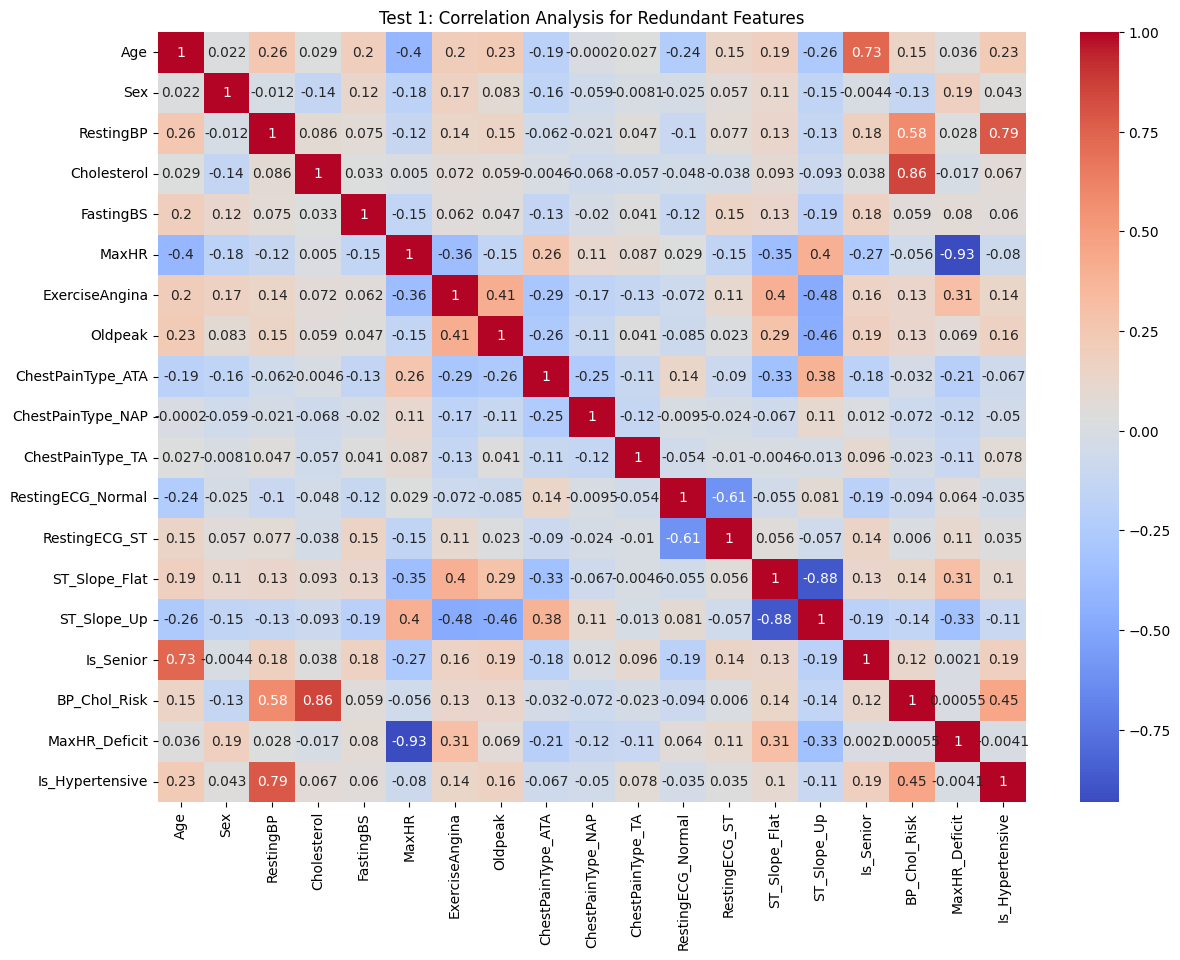

In [75]:
corr_matrix = X_train.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Test 1: Correlation Analysis for Redundant Features")
plt.show()

In [83]:
print("\nTEST 1 : REDUNDANT FEATURE PAIRS \n")

found_redundant_pair = False
for i in range(len(corr_matrix.columns)) : 
    for j in range(i) :

        if abs(corr_matrix.iloc[i,j])>0.85 : 
            colname1 = corr_matrix.columns[i]
            colname2 = corr_matrix.columns[j]
            score = corr_matrix.iloc[i, j]
            
            print(f": {colname1 :<15} || {colname2 :<15} (Score: {score:.2f})")
            found_pair = True

if found_pair==False : 
    print("No redundant pairs found with Pearson Correlation >0.85 or <-0.85")



TEST 1 : REDUNDANT FEATURE PAIRS 

: ST_Slope_Up     || ST_Slope_Flat   (Score: -0.88)
: BP_Chol_Risk    || Cholesterol     (Score: 0.86)
: MaxHR_Deficit   || MaxHR           (Score: -0.93)


##
### 3.5.2 - Variance Threshold Analysis
##

#### High Variance 
- If column 'Age' has ages from 20 to 80 ,  model will learn tracking heart disease for every age group
signifying high variance that column does not have same value most of the times ..
- If 50% are males and 50% are females in a column , this will give maximum variance of p(1-p) of 0.25
#### Low Variance 
- If one of columns for example  , 'IsHypertension' will have 99% 1s in column , meaning has hyper tension beacuse of high rest blood pressure , model will not learn much from this column , so this column can be reviewed to drop in future
- Industry Standard of low variance is capped at 0.01



In [85]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold = 0.01)

# We must use X_train here to prevent data leakage 
# selector.fit() is a tool used to calculate variance of every column in training data set here ..
selector.fit(X_train)

,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.01


In [89]:
print("\nTEST 2 :  LOW VARIANCE COLUMNS \n")

# after selector.fit(X_train) , selector.get_support gives true/false values for every column for test pass and fail
surviving_columns_high_variance = selector.get_support()
all_columns = X_train.columns

found_low_variance_col = False
for i in range(len(all_columns)): 
    if surviving_columns_high_variance[i] == False : 
        
        low_variance_col = all_columns[i]
        print((f" '{dead_col}' is identical for over 99% of patients."))
        found_low_variance_col = True

if found_low_variance_col == False :
    print("No Low variance Column found , every column passed this test")


TEST 2 :  LOW VARIANCE COLUMNS 

No Low variance Column found , every column passed this test


##
### 3.5.3 - ANNOVA F-Test Analysis
##

#### ANNOVA stands for analysis of variance 
- How it works ?
   - For example we run ANNOVA F-test on MaxHR column
       - It will split column with patients having heart disease(1) and not having heart disease(0) , as heart disease is target variable here . We ran variance threshhold analysis which calculated whole column variance individually , now we do it w.r.t target variable
       - It will calculate average maxhr for healthy patients
       - It will calculate average maxhr of sick patients
       - Compares the gap(distance) between those two values and generates "F-Score and p-value"


    - High F-Score means feature is important(high gap) and Low F-score means maxhr doesnt make any muxh difference as avg may come out to similar for both cases 

#### Chi-Squared Test or ANNOVA F-Test or Both ?
- Ideally :
    - We separate quantitative and categorical columns..
    - Chi squared test on Categorical Columns
    - ANNOVA F-Test on quantitative Columns
      


- Here :
    - We already turned our categorical columns into 0/1 by label encoding binary columns and one hot encoding multi-class categorical columns
    - ANNOVA F-test also works perfeclty well for binary(0/1) categorical columns as well , Thus we run ANNOVA F-test on all columns both Categorical ( where we ideally Chi-squared test ) and Quantitative Columns on training data set

In [97]:
from sklearn.feature_selection import SelectKBest , f_classif
# We use f_classif here becasue we are doing classification (predicting categorical variable)
# if we were doing Regression (predicting quantitative variable we would use f_regression)

anova_test = SelectKBest( score_func = f_classif , k='all')  
# k=all means we want to score all columns (both categorical and quantitative)

anova_test.fit(X_train , y_train) 
# we pass both here as we want variance to be calculated w.r.t target variable y_train

,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_c...001D0210A7E20>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",'all'


In [103]:
anova_results = pd.DataFrame (
    {
        'Feature': X_train.columns,
        'F_Score': anova_test.scores_,
        'p_value': anova_test.pvalues_
    }
)

anova_results = anova_results.sort_values(by='F_Score',ascending=False)
display(anova_results)

,Feature,F_Score,p_value
14,ST_Slope_Up,532.727079,5.453729e-89
13,ST_Slope_Flat,353.734449,1.117005e-64
6,ExerciseAngina,232.371210,9.003012e-46
5,MaxHR,145.522825,1.084541e-30
8,ChestPainType_ATA,136.599289,4.690689e-29
7,Oldpeak,120.977606,3.784657e-26
17,MaxHR_Deficit,99.717382,4.224929e-22
1,Sex,62.376915,1.039120e-14
4,FastingBS,53.682093,6.240608e-13
0,Age,46.618076,1.812908e-11


In [104]:
print("\nTEST 3 : FAILING FEATURES (p-value > 0.05)\n")
failing_features = anova_results[anova_results['p_value'] > 0.05]

if len(failing_features) > 0:
    display(failing_features)
else:
    print(" No features strictly failed the p-value test.")


TEST 3 : FAILING FEATURES (p-value > 0.05)



,Feature,F_Score,p_value
3,Cholesterol,3.584925,0.058700
10,ChestPainType_TA,1.820044,0.177725


- We can see here our 4 engineered features in feature engineering passed this test and columns we used (weak indicators) actually created a strong indicator

##
### 3.5.3 - Random Forest
##

#### To Understand Random Forest , we need to understand Decision Tree 
   - Decision Tree is a masssive flowchart of If/Then Questions
   - If St_Slope_Up == 1 ? Yes->Go left , No-> Go right
   - If MaxHR Deficit>40 ? Yes -> High Risk

#### Flaw of a Single Tree 
   - If we give single tree all of our data , it grow so deep and complex , it will memorize every data point including the random outliers n our training set which leads to overfitting
   - When a real patient comes along with werid data , it will not be able to recognize a pattern and fail as it never learnt it just memorized training dataset


#### Solution : Random Forest  
   - Instead of building a tree , we build a massive forest(usually 100 to 500 trees)
   - To prevent every tree from making same exact mistakes we inject "Randomness"

#### Randomness
   - Row randomness : Every tree is given slightly different , randomized handful of patients
   - Column randomness : Every time a tree asks a question , we blindfold it and only let it look at random subset of 3-4 columns instead of whole training dataset
   - Because of this randomness of fewer columns look , every tree is specialist in different area
       - Tree 1 becomes expert of Blood pressure
       - Tree 2 becomes expert of MaxHR deficit

#### Decision of Target Variable
   - When a new patient walks in , all 100 trees look at the patient and vote . If Tree 1 makes a mistake because of an outlier , it will not matter as other 99 trees will outvote it ..

#### How Random Forest Grades Features    (Gini Impurity)
   - Gini Impurity is the mathematical measurement of chaos (randomness or entropy)
   - It calculates how much chaos was removed , imagine node of 100 patients 50sick/50healthy(Chaos = 0.5) then we split up using ST_SlopeUp then 60 NOT have ST_SlopeUp(Left Group) and 40 HAS ST_SlopeUp(Right Group)
   - Out of Left Group (38 healthy , 2 are sick ) --> Low chaos (pure healthy) , Right Group (10/50Sick) --> Moderate chaos
   - It calculates weighted chaos of both trees
   - Initial(0.5) - weighted chaos after splitting = Total Chaos Removed from this tree
   - We sum chaos removed from every tree whenever splitting was done on this parameter (maxhr this example)

In [108]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators = 100 , random_state = 42)
rf_model.fit(X_train , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [111]:
rf_results = pd.DataFrame({
    'Feature' : X_train.columns,
    'Importance' : rf_model.feature_importances_
})

rf_results = rf_results.sort_values(by='Importance', ascending=False)
display(rf_results)

,Feature,Importance
14,ST_Slope_Up,0.168710
13,ST_Slope_Flat,0.104897
5,MaxHR,0.096526
7,Oldpeak,0.096328
17,MaxHR_Deficit,0.076034
6,ExerciseAngina,0.076031
3,Cholesterol,0.062321
0,Age,0.059807
16,BP_Chol_Risk,0.059312
2,RestingBP,0.053618


<Axes: xlabel='Importance', ylabel='Feature'>

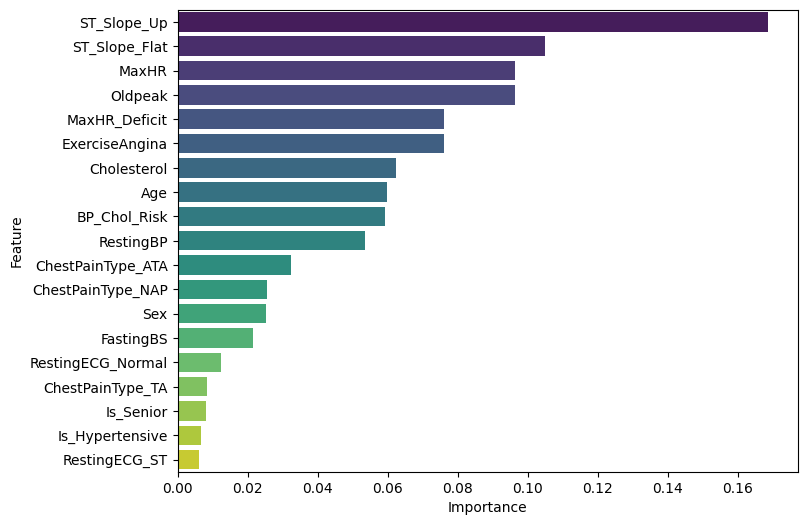

In [116]:
plt.figure(figsize=(8,6))
sns.barplot(x='Importance' , y = 'Feature' , data = rf_results , palette = 'viridis')

##
### 3.3 - Feature Scaling Testing - Training Dataset
##

#### Why we need Feature Scaling 

- If any machine learning algorithm sees Cholesterol as 280 and Oldpeak as 1.0 , algorithm will automatically assume Cholesterol is 280 times
more important than Oldpeak which eventually ignores Oldpeak which can also be a strong indicator while predicting HeartDisease4

- Feature Scaling shrinks every single quantative variable on exact same scale , so algorithm judges every parametere fairly

#### Why We didn't scale the whole dataset earlier ? 
- If we scale the whole dataset at once , algorithm will known Max/Min values of a column based on scaled values in a column which exposes overall data includind data of Test Set as well
  
- If our scaler sees the Test Set , it will give us fake accuracy maybe of 99% which will crash and fail when applied on an actual Hospital with patients
  
- Thus we only apply feature scaling on Training set independtly from Test Set . Then we apply same scale to Test set individually without fitting the new mean and std deviation of columns of test data set , we use same statistics to scale

- For example we think of scaling dataset of 5 patients with Cholesterol [100, 110, 120, 130, 300] . Avg calculates to be 152  , Now randomly data was split into first 4 patients and 5th patient as test data . Model has already learned baseline of Cholesterol as 152 . Only reason average is high because model peaked into test dataset while calculating average .

- This is called Data Leakage  , When model learns from test set which should not happen ..

- Thus we apply scaler.fit() only on training data thus our average cholesterol comes out to be 115 , thus when model sees 300 compares it to 115 and evaules as extreme outlier and high risk of heart diesease


#### Standarization ( Standard Scaler )

- Standard Scaler is industry default scaler because it is best to handle outliers with its z score formula . It tranforms data with centre as mean and forces the column average to be 0
- How to read Z score :
     - If a patient gets a {0}     : it means they are exactly perfectly average
     - If a patient gets a {+1.0}  : it means their number is higher than average.
     - If a patient gets a {+3.0}  : it means their number is insanely high (an extreme outlier).
     - If a patient gets a {-2.0}  :  it means their number is very low.

In [15]:
from sklearn.preprocessing import StandardScaler

quantitative_columns_to_scale = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
# we only scale quantative variables(0/1 are cateogoric)

# Initialziing the Scaler
scaler  = StandardScaler() 

# scaler.fit() looks at all the columns to scale and memorizes it average 
scaler.fit(X_train[quantitative_columns_to_scale])

# scaler.tranform() does the maths and changes the values in all columns 
# Transforming Training Data set
X_train[quantitative_columns_to_scale] = scaler.transform(X_train[quantitative_columns_to_scale])

# Tranforming Test Data set with same average of Training Data set
X_test[quantitative_columns_to_scale] = scaler.transform(X_test[quantitative_columns_to_scale])

In [16]:
print(" \nScaled Training Set  : \n")
display(X_train[quantitative_columns_to_scale].head())

print(" \nScaled Test Set  : \n")
display(X_test[quantitative_columns_to_scale].head())

 
Scaled Training Set  : 



,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
485,0.970012,0.339016,-0.539951,-0.324520,0.317046
486,0.122028,-1.266031,-0.595382,1.689837,-0.440356
117,0.546020,-0.159102,1.695768,-0.247045,0.601071
361,-0.725956,1.501291,-0.029246,-0.479470,-0.819056
296,-0.407962,0.671094,-0.029246,0.101594,-0.156330


 
Scaled Test Set  : 



,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
356,-0.831954,-0.989299,-0.029246,-0.905584,0.601071
763,0.440022,-0.048409,-0.410612,1.418673,2.210549
817,0.652018,-0.435834,0.217607,0.179069,1.831848
735,-0.513960,-0.712567,-1.075784,0.101594,1.074447
892,-1.573940,0.283669,-0.484520,0.605183,-0.819056


##
### 3.4 - Feature Engineering
##

####  3.4.1 - Is_Senior (Age>60)

- Person with age more than 60 are generally at higher risk of HeartDisease compared to 25-30 year old , Thus we make an Is_Senior Flag 

In [17]:

X_train['Is_Senior'] = np.where(X_train['Age']>=60,1,0)
X_test['Is_Senior'] = np.where(X_test['Age']>=60,1,0)

In [21]:
display(X_train[['Age','Is_Senior']].head(20))
display(X_test[['Age','Is_Senior']].head(20))

,Age,Is_Senior
485,0.970012,0
486,0.122028,0
117,0.546020,0
361,-0.725956,0
296,-0.407962,0
730,-0.513960,0
451,1.076010,0
291,-0.725956,0
92,-0.195966,0
765,-1.361944,0


,Age,Is_Senior
356,-0.831954,0
763,0.440022,0
817,0.652018,0
735,-0.513960,0
892,-1.573940,0
795,-1.255946,0
234,0.016030,0
383,-1.679938,0
642,-0.301964,0
454,0.440022,0
